In [1]:
from OOP_so_far import ModuleProperties, CombiningModules, RunSSA
from sympy import *
import numpy as np
import time
import matplotlib.pyplot as plt

/Users/willalston/Desktop/Msci_Project/git_repos/students/Will/Gillespie_simulations/OOP_so_far.py:1492: SyntaxWarning: invalid escape sequence '\m'
  chem_pot = symbols(f"\mu_{species_symbol}")


# Define Modules

In [7]:
# Module 1

SM = Matrix( [[-1,1,0], [1,-1,-1], [0,0,1], [-1,0,-1], [0,1,0]])

species_names = ["A1", "A2","A3","S","Na"]

num_internal_species = 3

# Module 2


SM2 = Matrix([[-1, 0, 1, 0, 0], # first row of internal
                           [1, -1, 0, -1, 0], 
                           [0, 1, -1, 0, 1], 
                           [0, 0, 0, 1, -1],
                             [0, 0, 0, -1, 0], # first row external 
                             [0, 0, 0, 0, 1],
                             [-1, 0, 0, 0, 0],
                             [0, 0, 1, 0, 0]])


species_names2 = ["B1", "B2", "B3", "B4", "Na", "Nb", "F", "W"]

num_internal_species2 = 4

# Module 3

SM3 = Matrix([
    [ 1, -1,  0,  0,  0,  0],  # EcNex
    [-1,  1, -1,  1,  0,  0],  # Ec
    [ 0,  0,  1, -1,  0,  0],  # EcNb
    [ 0,  0,  0,  0, -1,  1],  # Ec*
    [ 0,  0,  0,  0,  1, -1],  # Ec*Ne
    [ 0,  0,  0,  0, -1,  0],  # Ne
    [-1,  0,  0,  0,  0,  0],  # Nex
    [ 0,  0, -1,  0,  0,  0],  # Nb
    [ 0,  1,  0,  0,  0,  0],  # Pex
    [ 0,  0,  0,  1,  0,  0],  # Pb  # col 4 entry uncertain
    [ 0,  0,  0,  0,  0,  1],  # Pe
])

species_names3 = ["C1", "C2", "C3", "C4", "C5", "Ne", "Nex", "Nb", "Pex", "Pb", "Pe"]

# Module 4

SM4 = Matrix([
    [ 1,  1, -1,  0,  1],  # Ed
    [-1, -1,  1,  1,  0],  # EdS
    [ 0,  1,  0, -1, -1],  # Ed*
    [ 0,  0, -1, -1,  0],  # Nd
    [ 1,  0,  0,  0,  0],  # S
])

species_names4 = ["D1", "D2", "D3", "Nd", "S"]


# Create Module variables with moduleProps

In [8]:

module1 = ModuleProperties(SM, 3, species_names)
display(module1.calculate_fundamental_resistance_matrix())

module2 = ModuleProperties(SM2, 4, species_names2)
display(module2.calculate_fundamental_resistance_matrix())

module3 = ModuleProperties(SM3, 5, species_names3)
display(module3.calculate_fundamental_resistance_matrix())

module4 = ModuleProperties(SM4, 3, species_names4)
display(module4.calculate_fundamental_resistance_matrix())

[r₁ + r₂]

⎡r₂ + r₄ + r₅      -r₂     ⎤
⎢                          ⎥
⎣    -r₂       r₁ + r₂ + r₃⎦

⎡r₁ + r₂     0        0   ⎤
⎢                         ⎥
⎢   0     r₃ + r₄     0   ⎥
⎢                         ⎥
⎣   0        0     r₅ + r₆⎦

⎡r₁⋅r₃ + r₁⋅r₄ + r₁⋅r₅ + r₃⋅r₄ + r₃⋅r₅⎤
⎢─────────────────────────────────────⎥
⎣            r₃ + r₄ + r₅             ⎦

In [ ]:
module1.hyp

## Create JN1 and create CM

In [ ]:
JN1 = CombiningModules(module1, module2)

print("JN1 overall SelM: ")
pprint(JN1.selection_matrix)

JN1_CM = JN1.fundamental_conductance_matrix

JN1.fundamental_resistance_matrix # Print the Resistance Matrix as it is simpler

# JN1_mod = ModuleProperties(JN1.stoich_matrix, JN1.num_internal_species, JN1.species_names)
# JN1_mod.calculate_fundamental_resistance_matrix()

JN1 overall SelM: 
⎡-1  0 ⎤
⎢      ⎥
⎢1   0 ⎥
⎢      ⎥
⎢0   -1⎥
⎢      ⎥
⎣0   1 ⎦


⎡r₁ + r₂ + r₅ + r₇ + r₈      -r₅     ⎤
⎢                                    ⎥
⎣         -r₅            r₄ + r₅ + r₆⎦

## Create JN2 and create CM

In [ ]:
JN2 = CombiningModules(JN1_mod, module3)

JN2_CM = JN2.fundamental_conductance_matrix

JN2.fundamental_resistance_matrix # Print the Resistance Matrix as it is simpler

# JN2_mod = ModuleProperties(JN2.stoich_matrix, JN2.num_internal_species, JN2.species_names)
# JN2_mod.calculate_fundamental_resistance_matrix()

JN2 overall SelM: 
⎡-1  0   0   0 ⎤
⎢              ⎥
⎢1   0   0   0 ⎥
⎢              ⎥
⎢0   0   0   -1⎥
⎢              ⎥
⎢0   -1  0   0 ⎥
⎢              ⎥
⎢0   0   -1  0 ⎥
⎢              ⎥
⎢0   1   0   0 ⎥
⎢              ⎥
⎢0   0   1   0 ⎥
⎢              ⎥
⎣0   0   0   1 ⎦


⎡     r₁₀                       r₉        r₁₀   r₉                             ↪
⎢r₁ + ─── + r₂ + r₅ + r₇ + r₈ + ──        ─── + ──             0               ↪
⎢      4                        4          4    4                              ↪
⎢                                                                              ↪
⎢            r₁₀   r₉               r₁₀   r₁₃   r₁₄   r₉                       ↪
⎢            ─── + ──               ─── + ─── + ─── + ──       0               ↪
⎢             4    4                 4     4     4    4                        ↪
⎢                                                                              ↪
⎢                                                          r₁₁   r₁₂           ↪
⎢                0                           0             ─── + ───           ↪
⎢                                                           4     4            ↪
⎢                                                                              ↪
⎢                           

 # Create JN3 and create CM for full network

In [26]:
JN3 = CombiningModules(module4, JN2_mod)

# JN3_CM = JN3.fundamental_conductance_matrix

JN3.fundamental_resistance_matrix # Print the Resistance Matrix as it is simpler

JN3 overall SelM: 
⎡-1  0   0   0 ⎤
⎢              ⎥
⎢1   0   0   0 ⎥
⎢              ⎥
⎢0   0   0   -1⎥
⎢              ⎥
⎢0   -1  0   0 ⎥
⎢              ⎥
⎢0   0   -1  0 ⎥
⎢              ⎥
⎢0   1   0   0 ⎥
⎢              ⎥
⎢0   0   1   0 ⎥
⎢              ⎥
⎣0   0   0   1 ⎦


⎡                  r₁₄   r₁₅             r₁⋅r₃ + r₁⋅r₄ + r₁⋅r₅ + r₃⋅r₄ + r₃⋅r₅ ↪
⎢r₁₀ + r₁₂ + r₁₃ + ─── + ─── + r₆ + r₇ + ───────────────────────────────────── ↪
⎢                   4     4                          r₃ + r₄ + r₅              ↪
⎢                                                                              ↪
⎢                                  r₁₄   r₁₅                                   ↪
⎢                                  ─── + ───                                   ↪
⎢                                   4     4                                    ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                      0                                       ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                           

### Create new module variable for JN3

In [ ]:

JN3_mod = ModuleProperties(JN3.stoich_matrix, JN3.num_internal_species, JN3.species_names)

JN3_direct_R = JN3_mod.calculate_fundamental_resistance_matrix() # requirement to build

JN3_direct_R

⎡r₁₀ + r₁₁ + r₉      0                                                         ↪
⎢                                                                              ↪
⎢      0         r₁₄ + r₁₅                                                     ↪
⎢                                                                              ↪
⎢                           r₁⋅r₃ + r₁⋅r₄ + r₁⋅r₅ + r₁₀⋅r₃ + r₁₀⋅r₄ + r₁₀⋅r₅ + ↪
⎢     -r₁₀           0      ────────────────────────────────────────────────── ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎣      0             0                                                         ↪

↪                                                           -r₁₀               ↪
↪                                                                              ↪
↪                                                            0                 ↪
↪                          

#  speed comparison

In [ ]:
# Direct method: 

SM_direct

d1 = time.time()

JN3_mod.calculate_fundamental_resistance_matrix()

d2 = time.time()

print(d2 -d1)


In [ ]:
# Combination method

JN1 = CombiningModules(module1, module2)
JN1_mod = ModuleProperties(JN1.stoich_matrix, JN1.num_internal_species, JN1.species_names)


JN2 = CombiningModules(JN1_mod, module3)
JN2_mod = ModuleProperties(JN2.stoich_matrix, JN2.num_internal_species, JN2.species_names)


JN3 = CombiningModules(module4, JN2_mod)
JN3_mod = ModuleProperties(JN3.stoich_matrix, JN3.num_internal_species, JN3.species_names)



# Iteration plots

In [5]:
simulation_length = 1000.0

burn_in = 200.0

initial_counts = [350, 350, 350, 50, 50]

rates = 0.1 * np.array([0.005, 0.8, 0.6, 0.002, 0.012, 0.5])

SIM1 = RunSSA(module1, initial_counts, rates, simulation_length, burn_in)

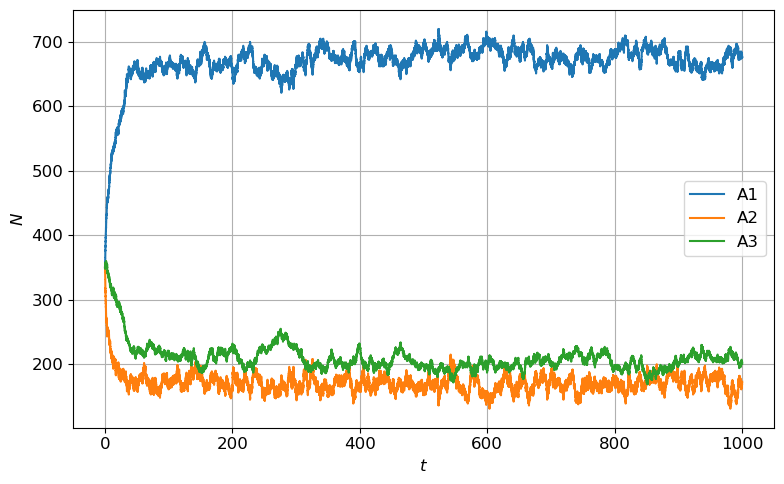

In [24]:
SIM1.run_SSA_and_plot_counts(True)

In [7]:
num_iterations = np.linspace(1,1000,150,dtype=int)

raw_Is = []
raw_Fs = []

I_vars = []
F_vars = []

times = []

for iteration in num_iterations:

    t1 = time.time()

    M1_curr, M1_forr = SIM1.run_IF_sweep([0],
                np.array([[initial_counts[0]]]),
                iteration,
                covariance_reaction_indices=None,
                verbose=False)
    
    t2 = time.time()

    times.append(t2-t1)
    raw_Is.append(M1_curr)
    raw_Fs.append(M1_forr)
    I_vars.append(SIM1.sweep_I_variances)
    F_vars.append(SIM1.sweep_F_variances)

    print(iteration)
    


1
7
14
21
27
34
41
47
54
61
68
74
81
88
94
101
108
114
121
128
135
141
148
155
161
168
175
182
188
195
202
208
215
222
228
235
242
249
255
262
269
275
282
289
296
302
309
316
322
329
336
342
349
356
363
369
376
383
389
396
403
409
416
423
430
436
443
450
456
463
470
477
483
490
497
503
510
517
523
530
537
544
550
557
564
570
577
584
591
597
604
611
617
624
631
637
644
651
658
664
671
678
684
691
698
704
711
718
725
731
738
745
751
758
765
772
778
785
792
798
805
812
818
825
832
839
845
852
859
865
872
879
886
892
899
906
912
919
926
932
939
946
953
959
966
973
979
986
993
1000


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


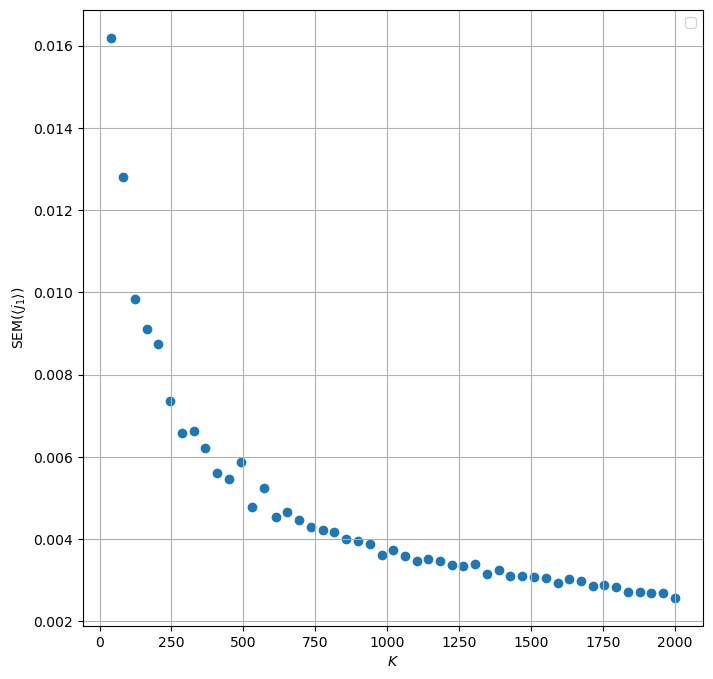

In [96]:
import matplotlib.pyplot as plt
# from scipy.optimize import curve_fit

# def sem_model(K, a):
#     return a / np.sqrt(K)

# popt, _ = curve_fit(sem_model, num_iterations, scaled_I_1)
# K_fit = np.linspace(1, 2000, 500)
# plt.plot(K_fit, sem_model(K_fit, *popt), 'r--', label=r'$a/\sqrt{K}$ fit')
plt.scatter(num_iterations,scaled_I_1)#, label=r'Var$\left(\left<j_1\right>\right)$')
# plt.scatter(num_iterations,scaled_I_2, label=r'j_2')
# plt.scatter(num_iterations,scaled_I_3, label=r'j_{3}')
plt.xlabel(r'$K$')
plt.ylabel(r'SEM$\left(\left<j_1\right>\right)$')
plt.grid(True)
# plt.axhline(0.1*scaled_I_1[1])
plt.legend()
plt.show()

In [67]:
scaled_I_1 = []
scaled_I_2 = []
scaled_I_3 = []

for n in range(len(I_vars)):

    scaled_I_1.append(np.sqrt(I_vars[n][0][0]) / np.sqrt(num_iterations[n]))
    scaled_I_2.append(np.sqrt(I_vars[n][0][1]) / np.sqrt(num_iterations[n]))
    scaled_I_3.append(np.sqrt(I_vars[n][0][2]) / np.sqrt(num_iterations[n]))


In [17]:
I_vars

[array([[nan, nan, nan]]),
 array([[0.06094992, 0.04871851, 0.00088478]]),
 array([[0.00935935, 0.01198768, 0.00028189]]),
 array([[0.02371035, 0.02318359, 0.00059664]]),
 array([[0.01100427, 0.00990511, 0.00060282]]),
 array([[0.01920301, 0.01677488, 0.00055255]]),
 array([[0.01562766, 0.01422995, 0.00052915]]),
 array([[0.01282119, 0.01457104, 0.00045403]]),
 array([[0.01359387, 0.01247531, 0.00063046]]),
 array([[0.01220581, 0.01261401, 0.00053884]]),
 array([[0.01283425, 0.01175289, 0.00063205]]),
 array([[0.01383813, 0.01322129, 0.00067859]]),
 array([[0.01522703, 0.01436049, 0.00048481]]),
 array([[0.01093461, 0.01078788, 0.00050851]]),
 array([[0.01501128, 0.01538917, 0.0005015 ]]),
 array([[0.02142115, 0.02010077, 0.00068438]]),
 array([[0.01494425, 0.01372536, 0.00041741]]),
 array([[0.01280493, 0.01298595, 0.0004188 ]]),
 array([[0.01373788, 0.01306292, 0.00047961]]),
 array([[0.0111289 , 0.01174074, 0.00041428]]),
 array([[0.0156414 , 0.01469005, 0.00058192]]),
 array([[0.01

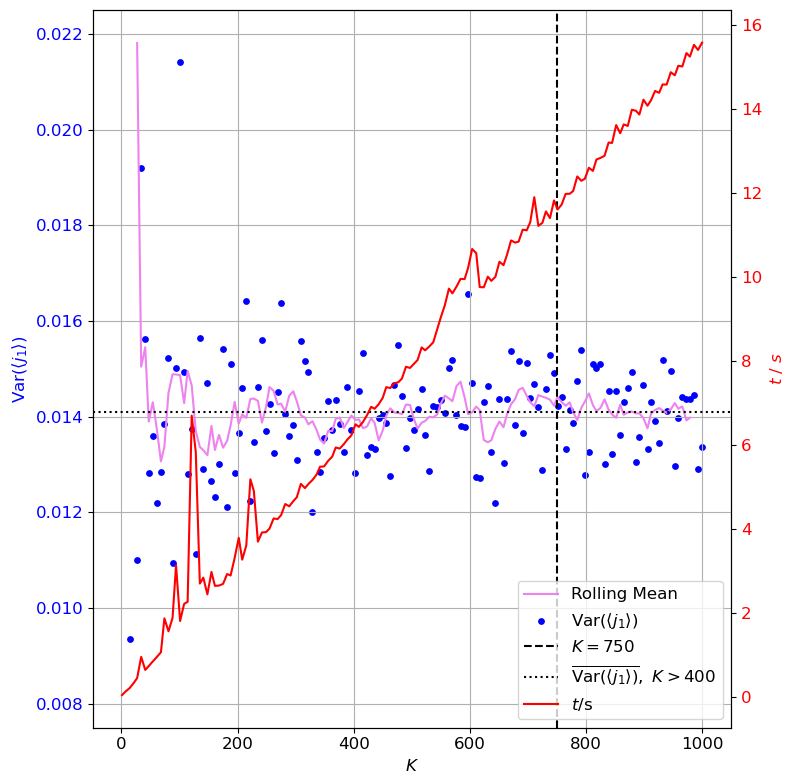

In [14]:
plt.rcParams.update({'font.size': 12})
fig, ax1 = plt.subplots()

import pandas as pd

var_series = pd.Series([sub[0][0] for sub in I_vars])
rolling = var_series.rolling(window=7, center=True).mean()


ax1.plot(num_iterations, rolling, color='violet', linewidth=1.5,
         label=r'Rolling Mean')
# Left y-axis: variance
ax1.scatter(num_iterations, [sub[0][0] for sub in I_vars], color='blue', label=r'Var$\left(\left\langle j_1 \right\rangle\right)$',s=15)
ax1.set_xlabel(r'$K$')
ax1.set_ylabel(r'Var$\left(\left\langle j_1 \right\rangle\right)$', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Right y-axis: computation time
ax2 = ax1.twinx()
ax2.plot(num_iterations, times, color='red', label=r'$t/\mathrm{s}$')
ax2.set_ylabel(r'$t$ / $s$', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Optional: mark chosen K
chosen_K = 750
ax1.axvline(chosen_K, color='black', linestyle='--', label=f'$K = {chosen_K}$', alpha=1)

ax1.axhline(np.mean([sub[0][0] for sub in I_vars][60:]), label=r'$\overline{\mathrm{Var}(\langle j_1 \rangle)},\ K > 400$', linestyle=':', alpha=1, linewidth=1.5, color='black')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')

ax1.grid(True, axis='both')
plt.tight_layout()
ax1.set_ylim(0.0075,0.0225)

plt.savefig('var_time_vs_iterations.png', dpi=300, bbox_inches='tight')
plt.show()

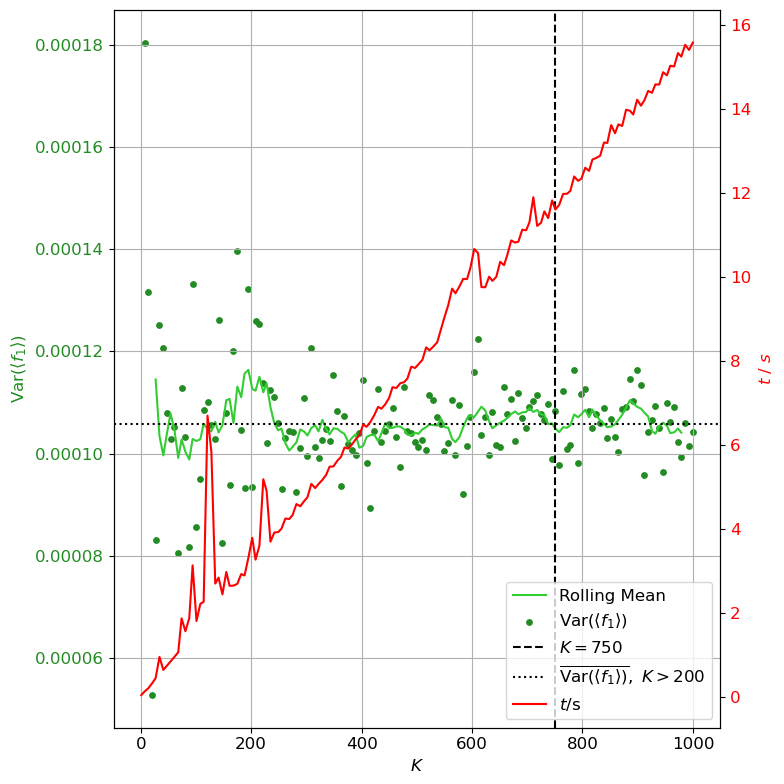

In [11]:
plt.rcParams.update({'font.size': 12})
fig, ax1 = plt.subplots()

import pandas as pd

var_series = pd.Series([sub[0][0] for sub in F_vars])
rolling = var_series.rolling(window=7, center=True).mean()


ax1.plot(num_iterations, rolling, color='limegreen', linewidth=1.5,
         label=r'Rolling Mean')
# Left y-axis: variance
ax1.scatter(num_iterations, [sub[0][0] for sub in F_vars], color='forestgreen', label=r'Var$\left(\left\langle f_1 \right\rangle\right)$',s=15)
ax1.set_xlabel(r'$K$')
ax1.set_ylabel(r'Var$\left(\left\langle f_1 \right\rangle\right)$', color='forestgreen')
ax1.tick_params(axis='y', labelcolor='forestgreen')

# Right y-axis: computation time
ax2 = ax1.twinx()
ax2.plot(num_iterations, times, color='red', label=r'$t/\mathrm{s}$')
ax2.set_ylabel(r'$t$ / $s$', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Optional: mark chosen K
chosen_K = 750
ax1.axvline(chosen_K, color='black', linestyle='--', label=f'$K = {chosen_K}$', alpha=1)

ax1.axhline(np.mean([sub[0][0] for sub in F_vars][30:]), label=r'$\overline{\mathrm{Var}(\langle f_1 \rangle)},\ K > 200$', linestyle=':', alpha=1, linewidth=1.5, color='black')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')

ax1.grid(True, axis='both')
plt.tight_layout()
# ax1.set_ylim(0.0075,0.0225)

plt.savefig('var_force_time_vs_iterations.png', dpi=300, bbox_inches='tight')
plt.show()

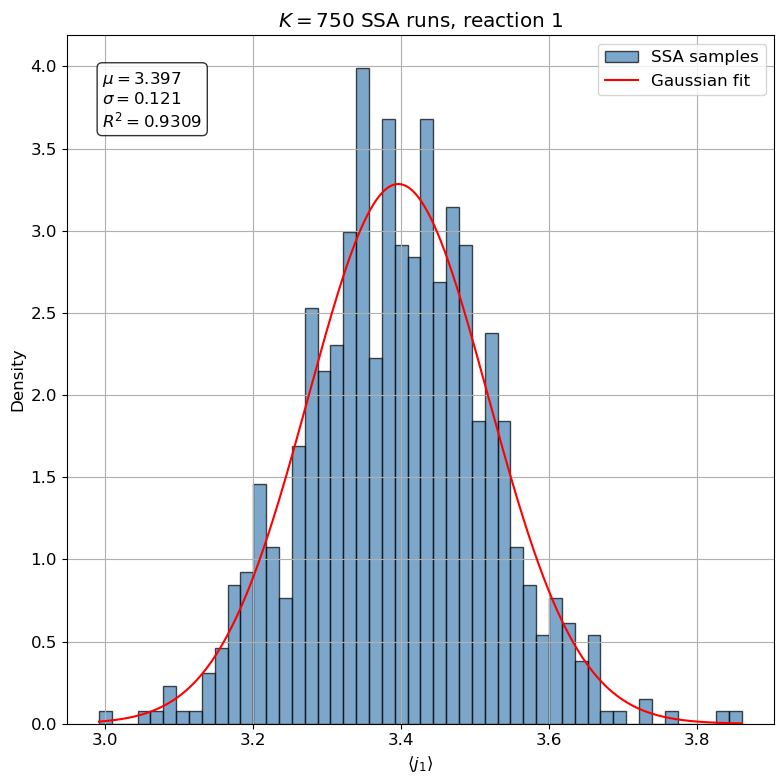

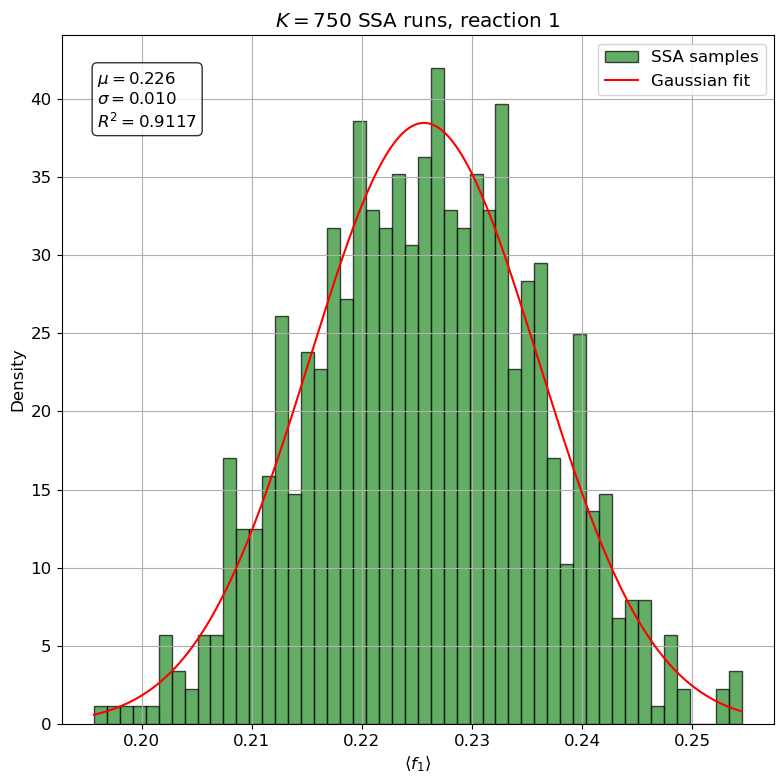

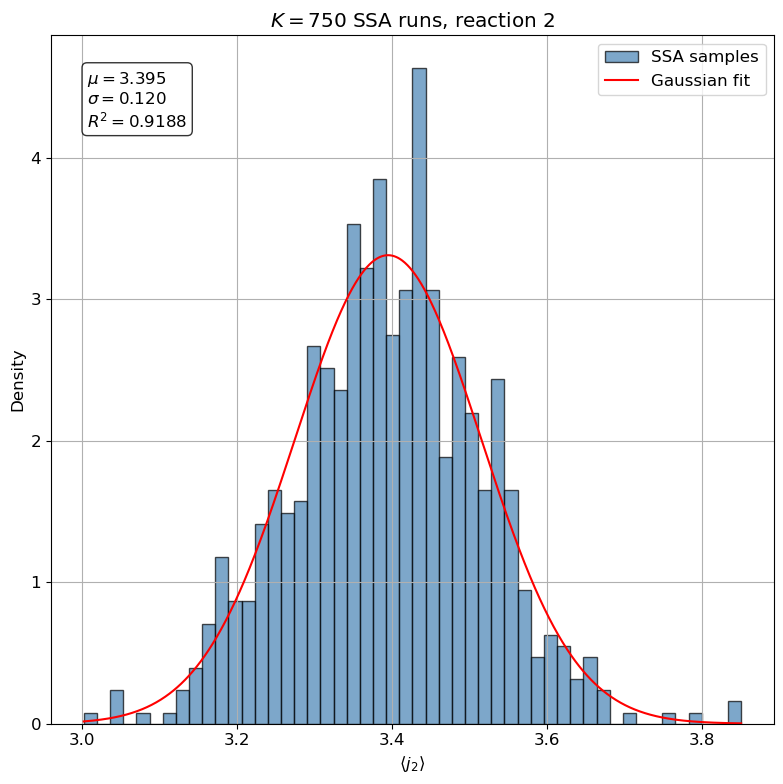

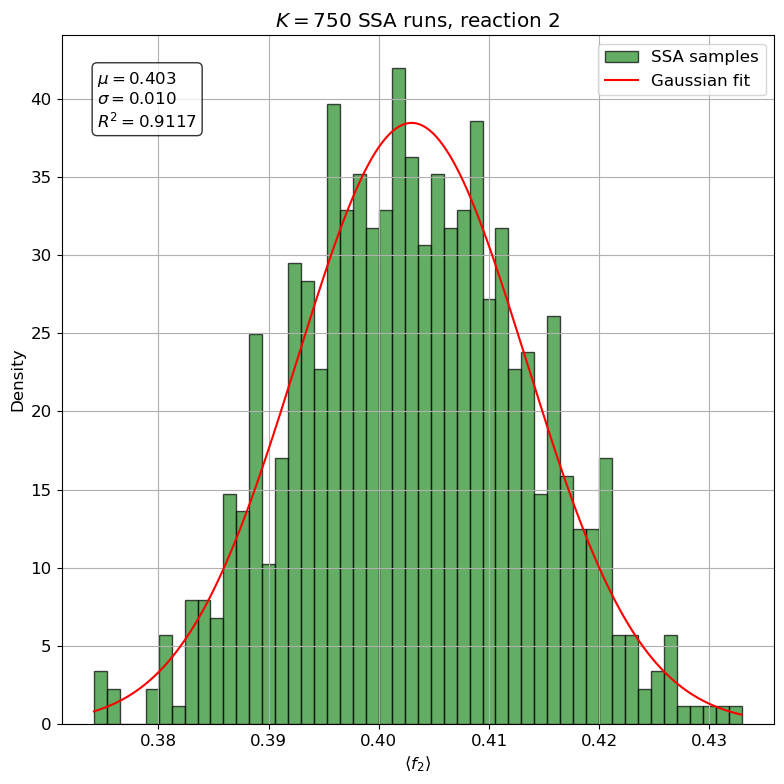

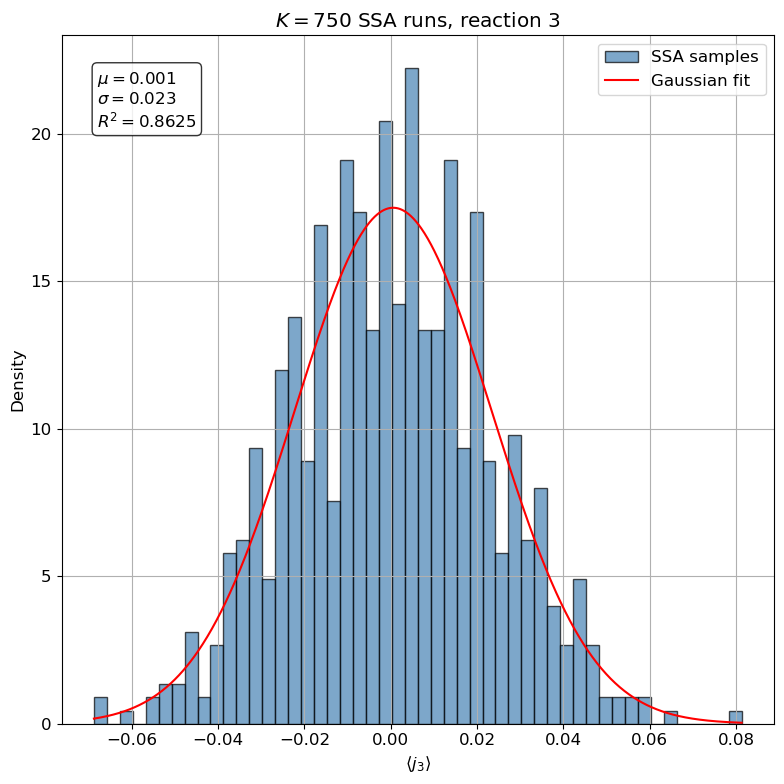

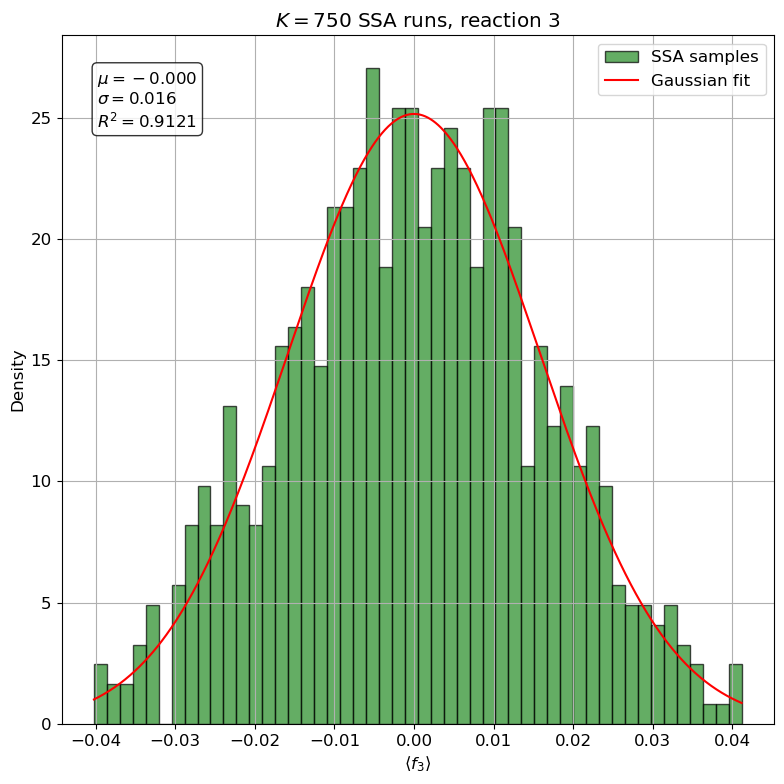

In [13]:
SIM1.plot_gaussian_comparison(
            
            bins=50,
            num_iterations=750,
            Gaussian_points=1000
            )

# Conductance combination and comparison with Na chemosttated vs Na SS values

## Seperate conductance plots

In [5]:
simulation_length = 1000.0

burn_in = 200.0

initial_counts = [350, 350, 350, 50, 50]

rates = 0.1 * np.array([0.005, 0.8, 0.6, 0.002, 0.012, 0.5])

SIM1 = RunSSA(module1, initial_counts, rates, simulation_length, burn_in)

initial_counts2 = [350, 350, 350, 350, 50, 50, 50, 50]

rates2 = 0.1 * np.array([0.01, 1.0, 1.0, 0.5, 1.5, 0.01, 0.01, 1.0, 1.2, 0.01])

SIM2 = RunSSA(module2, initial_counts2, rates2, simulation_length,burn_in)

# SIM2.run_SSA_and_plot_counts(True)

NameError: name 'module1' is not defined

In [24]:
SIM2.species_names

['B1', 'B2', 'B3', 'B4', 'Na', 'Nb', 'F', 'W']

In [8]:
# def plot_conductance_publishable(
#     sim_obj,
#     analytical_G=None,
#     marker_size=60,
#     cmap='viridis',
#     show_covariance=True,
#     species_index=0,
#     x_axis_label=None,
#     save_name='conductance_plot.png'
# ):
#     """
#     Publishable-quality conductance plot, designed to run outside the RunSSA class.

#     Parameters
#     ----------
#     sim_obj : RunSSA
#         The simulation object after run_IF_sweep() and compute_conductances() have been called.
#     analytical_G : array-like, optional
#         Analytical/combined conductance eigenvalues for comparison.
#     marker_size : int
#         Scatter marker size.
#     cmap : str
#         Colormap for EPR colour grading.
#     show_covariance : bool
#         Whether to plot ||Cov(I)/2||.
#     species_index : int
#         Index into sim_obj.count_values for the x-axis species.
#     x_axis_label : str, optional
#         Custom x-axis label. If None, uses species name from sim_obj.
#     save_name : str
#         Filename for saved figure.
#     """

#     import matplotlib as mpl
    
#     plt.rcParams.update({'font.size': 12})

#     # ── Data extraction ───────────────────────────────────────────────────────

#     x_axis_for_plot = sim_obj.count_values[species_index]

#     if x_axis_label is None:
#         x_axis_label = r'$[' + sim_obj.species_names[sim_obj.species_index[species_index]] + r']$'

#     n_sweeps = len(sim_obj.count_values[0])

#     if analytical_G is None and hasattr(sim_obj, 'analytical_G'):
#         analytical_G = sim_obj.analytical_G

#     # ── IQR outlier filtering ─────────────────────────────────────────────────

#     eigvals = sim_obj.sweep_G_eigenvalues.copy()
#     for e in range(eigvals.shape[1]):
#         col = eigvals[:, e]
#         Q1 = np.nanpercentile(col, 25)
#         Q3 = np.nanpercentile(col, 75)
#         IQR = Q3 - Q1
#         eigvals[:, e] = np.where(
#             (col > Q3 + 3 * IQR) | (col < Q1 - 3 * IQR), np.nan, col
#         )

#     n_indep = eigvals.shape[1]

#     # ── Scalar case ───────────────────────────────────────────────────────────

#     if sim_obj.conductance_type == 'scalar':

#         fig, ax = plt.subplots(figsize=(8, 5))

#         sc = ax.scatter(
#             x_axis_for_plot, sim_obj.sweep_G_scalar,
#             c=sim_obj.fundamental_EPRs, cmap=cmap,
#             s=marker_size*0.8, edgecolors='black', linewidths=0.5,
#             label=r'$G$ (SSA)', zorder=3
#         )
#         cbar = fig.colorbar(sc, ax=ax)
#         cbar.set_label(r'$\dot{\sigma}$')

#         if analytical_G is not None:
#             ax.scatter(
#                 x_axis_for_plot, analytical_G,
#                 marker='x', c='red', s=marker_size*0.8,
#                 label=r'$G$ (Combined)', zorder=4
#             )

#         if show_covariance:
#             cov_half = np.array([
#                 sim_obj.sweep_covariance_matrices[s][0, 0] / 2.0
#                 for s in range(n_sweeps)
#             ])
#             # IQR filter covariance too
#             Q1 = np.nanpercentile(cov_half, 25)
#             Q3 = np.nanpercentile(cov_half, 75)
#             cov_half = np.where(cov_half > Q3 + 3*(Q3-Q1), np.nan, cov_half)

#             ax.scatter(
#                 x_axis_for_plot, cov_half,
#                 marker='x', color='blue', s=marker_size * 0.3,
#                 alpha=0.3, label=r'$\mathrm{Cov}(I) / 2$', zorder=3
#             )

#         ax.set_xlabel(x_axis_label)
#         ax.set_ylabel(r'$G$')
#         ax.legend()
#         ax.grid(True)
#         fig.tight_layout()
#         plt.savefig(save_name, dpi=300, bbox_inches='tight')
#         plt.show()

#     # ── Matrix case ───────────────────────────────────────────────────────────

#     else:

#         norm = mpl.colors.Normalize(
#             vmin=np.nanmin(sim_obj.fundamental_EPRs),
#             vmax=np.nanmax(sim_obj.fundamental_EPRs)
#         )
#         sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
#         sm.set_array([])

#         markers = ['o', 's', '^', 'D', 'v', 'P']

#         # ── Combined plot ─────────────────────────────────────────────────────

#         fig, ax = plt.subplots(figsize=(8, 5))

#         for e in range(n_indep):
#             ax.scatter(
#                 x_axis_for_plot, eigvals[:, e],
#                 c=sim_obj.fundamental_EPRs,
#                 cmap=cmap, norm=norm,
#                 s=marker_size*0.8,
#                 marker=markers[e % len(markers)],
#                 edgecolors='black', linewidths=0.5,
#                 label=fr'$\lambda_{{{e+1}}}(\mathbf{{G}})$',
#                 zorder=3
#             )

#         if analytical_G is not None:
#             analytical_G_np = np.array(analytical_G)
#             if analytical_G_np.ndim == 1:
#                 ax.scatter(
#                     x_axis_for_plot, analytical_G_np,
#                     marker='x', color='red', s=marker_size*0.8,
#                     label=r'$G$ (Combined)', zorder=4
#                 )
#             else:
#                 for e in range(analytical_G_np.shape[1]):
#                     ax.scatter(
#                         x_axis_for_plot, analytical_G_np[:, e],
#                         marker='x', color='red', s=marker_size*0.8,
#                         label=fr'$\lambda_{{{e+1}}}(\mathbf{{G}})$ (Combined)',
#                         zorder=4
#                     )

#         if show_covariance:
#             cov_spectral_norms = np.array([
#                 np.linalg.norm(0.5 * sim_obj.sweep_covariance_matrices[s], 2)
#                 for s in range(n_sweeps)
#             ])
#             # IQR filter
#             Q1 = np.nanpercentile(cov_spectral_norms, 25)
#             Q3 = np.nanpercentile(cov_spectral_norms, 75)
#             cov_spectral_norms = np.where(
#                 cov_spectral_norms > Q3 + 3*(Q3-Q1), np.nan, cov_spectral_norms
#             )
#             ax.scatter(
#                 x_axis_for_plot, cov_spectral_norms,
#                 marker='x', color='blue', s=marker_size * 0.3,
#                 alpha=0.5, label=r'$\|\mathrm{Cov}(\mathbf{I})/2\|$',
#                 zorder=3
#             )

#         cbar = fig.colorbar(sm, ax=ax)
#         cbar.set_label(r'$\sigma$')
#         ax.set_xlabel(x_axis_label)
#         ax.set_ylabel(r'$\lambda(\mathbf{G})$')
#         ax.legend()
#         ax.grid(True)
#         fig.tight_layout()
#         plt.savefig(save_name, dpi=300, bbox_inches='tight')
#         plt.show()

        

def plot_conductance_publishable(
    sim_obj,
    analytical_G=None,
    marker_size=60,
    cmap='viridis',
    show_covariance=True,
    species_index=0,
    x_axis_label=None,
    save_name='conductance_plot.png'
):
    """
    Publishable-quality conductance plot, designed to run outside the RunSSA class.

    Parameters
    ----------
    sim_obj : RunSSA
        The simulation object after run_IF_sweep() and compute_conductances() have been called.
    analytical_G : array-like, optional
        Analytical/combined conductance eigenvalues for comparison.
    marker_size : int
        Scatter marker size.
    cmap : str
        Colormap for EPR colour grading.
    show_covariance : bool
        Whether to plot ||Cov(I)/2||.
    species_index : int
        Index into sim_obj.count_values for the x-axis species.
    x_axis_label : str, optional
        Custom x-axis label. If None, uses species name from sim_obj.
    save_name : str
        Filename for saved figure.
    """

    import matplotlib as mpl
    
    plt.rcParams.update({'font.size': 12})

    # ── Data extraction ───────────────────────────────────────────────────────

    x_axis_for_plot = sim_obj.count_values[species_index]

    if x_axis_label is None:
        x_axis_label = r'$[' + sim_obj.species_names[sim_obj.species_index[species_index]] + r']$'

    n_sweeps = len(sim_obj.count_values[0])

    if analytical_G is None and hasattr(sim_obj, 'analytical_G'):
        analytical_G = sim_obj.analytical_G

    # ── IQR outlier filtering for eigenvalues ─────────────────────────────────

    if sim_obj.conductance_type != 'scalar':
        eigvals = sim_obj.sweep_G_eigenvalues.copy()
        for e in range(eigvals.shape[1]):
            col = eigvals[:, e]
            Q1 = np.nanpercentile(col, 25)
            Q3 = np.nanpercentile(col, 75)
            IQR = Q3 - Q1
            eigvals[:, e] = np.where(
                (col > Q3 + 3 * IQR) | (col < Q1 - 3 * IQR), np.nan, col
            )
        n_indep = eigvals.shape[1]

    # ── IQR outlier filtering for scalar conductance ──────────────────────────
    
    if sim_obj.conductance_type == 'scalar':
        G_scalar = sim_obj.sweep_G_scalar.copy()
        Q1 = np.nanpercentile(G_scalar, 25)
        Q3 = np.nanpercentile(G_scalar, 75)
        IQR = Q3 - Q1
        G_scalar = np.where(
            (G_scalar > Q3 + 3 * IQR) | (G_scalar < Q1 - 3 * IQR), np.nan, G_scalar
        )

    # ── Scalar case ───────────────────────────────────────────────────────────

    if sim_obj.conductance_type == 'scalar':

        fig, ax = plt.subplots(figsize=(8, 5))

        sc = ax.scatter(
            x_axis_for_plot, G_scalar,
            c=sim_obj.fundamental_EPRs, cmap=cmap,
            s=marker_size*0.8, edgecolors='black', linewidths=0.5,
            label=r'$G$ (SSA)', zorder=3
        )
        cbar = fig.colorbar(sc, ax=ax)
        cbar.set_label(r'$\dot{\sigma}$')

        if analytical_G is not None:
            ax.scatter(
                x_axis_for_plot, analytical_G,
                marker='x', c='red', s=marker_size*0.8,
                label=r'$G$ (Combined)', zorder=4
            )

        if show_covariance:
            cov_half = np.array([
                sim_obj.sweep_covariance_matrices[s][0, 0] / 2.0
                for s in range(n_sweeps)
            ])
            # IQR filter covariance
            Q1_cov = np.nanpercentile(cov_half, 25)
            Q3_cov = np.nanpercentile(cov_half, 75)
            IQR_cov = Q3_cov - Q1_cov
            cov_half = np.where(
                (cov_half > Q3_cov + 3 * IQR_cov) | (cov_half < Q1_cov - 3 * IQR_cov), 
                np.nan, cov_half
            )

            ax.scatter(
                x_axis_for_plot, cov_half,
                marker='x', color='blue', s=marker_size * 0.3,
                alpha=0.3, label=r'$\mathrm{Cov}(I) / 2$', zorder=3
            )

        ax.set_xlabel(x_axis_label)
        ax.set_ylabel(r'$G$')
        ax.legend()
        ax.grid(True)
        fig.tight_layout()
        plt.savefig(save_name, dpi=300, bbox_inches='tight')
        plt.show()

    # ── Matrix case ───────────────────────────────────────────────────────────

    else:

        norm = mpl.colors.Normalize(
            vmin=np.nanmin(sim_obj.fundamental_EPRs),
            vmax=np.nanmax(sim_obj.fundamental_EPRs)
        )
        sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])

        markers = ['o', 's', '^', 'D', 'v', 'P']

        # ── Combined plot ─────────────────────────────────────────────────────

        fig, ax = plt.subplots(figsize=(8, 5))

        for e in range(n_indep):
            ax.scatter(
                x_axis_for_plot, eigvals[:, e],
                c=sim_obj.fundamental_EPRs,
                cmap=cmap, norm=norm,
                s=marker_size*0.8,
                marker=markers[e % len(markers)],
                edgecolors='black', linewidths=0.5,
                label=fr'$\lambda_{{{e+1}}}(\mathbf{{G}})$',
                zorder=3
            )

        if analytical_G is not None:
            analytical_G_np = np.array(analytical_G)
            if analytical_G_np.ndim == 1:
                ax.scatter(
                    x_axis_for_plot, analytical_G_np,
                    marker='x', color='red', s=marker_size*0.8,
                    label=r'$G$ (Combined)', zorder=4
                )
            else:
                for e in range(analytical_G_np.shape[1]):
                    ax.scatter(
                        x_axis_for_plot, analytical_G_np[:, e],
                        marker='x', color='red', s=marker_size*0.8,
                        label=fr'$\lambda_{{{e+1}}}(\mathbf{{G}})$ (Combined)',
                        zorder=4
                    )

        if show_covariance:
            cov_spectral_norms = np.array([
                np.linalg.norm(0.5 * sim_obj.sweep_covariance_matrices[s], 2)
                for s in range(n_sweeps)
            ])
            # IQR filter
            Q1 = np.nanpercentile(cov_spectral_norms, 25)
            Q3 = np.nanpercentile(cov_spectral_norms, 75)
            IQR = Q3 - Q1
            cov_spectral_norms = np.where(
                (cov_spectral_norms > Q3 + 3 * IQR) | (cov_spectral_norms < Q1 - 3 * IQR), 
                np.nan, cov_spectral_norms
            )
            ax.scatter(
                x_axis_for_plot, cov_spectral_norms,
                marker='x', color='blue', s=marker_size * 0.3,
                alpha=0.5, label=r'$\|\mathrm{Cov}(\mathbf{I})/2\|$',
                zorder=3
            )

        cbar = fig.colorbar(sm, ax=ax)
        cbar.set_label(r'$\sigma$')
        ax.set_xlabel(x_axis_label)
        ax.set_ylabel(r'$\lambda(\mathbf{G})$')
        ax.legend()
        ax.grid(True)
        fig.tight_layout()
        plt.savefig(save_name, dpi=300, bbox_inches='tight')
        plt.show()

Sweep 1/35  ([S] = 75)
Sweep 2/35  ([S] = 87)
Sweep 3/35  ([S] = 100)
Sweep 4/35  ([S] = 112)
Sweep 5/35  ([S] = 125)
Sweep 6/35  ([S] = 137)
Sweep 7/35  ([S] = 150)
Sweep 8/35  ([S] = 162)
Sweep 9/35  ([S] = 175)
Sweep 10/35  ([S] = 187)
Sweep 11/35  ([S] = 200)
Sweep 12/35  ([S] = 212)
Sweep 13/35  ([S] = 225)
Sweep 14/35  ([S] = 237)
Sweep 15/35  ([S] = 250)
Sweep 16/35  ([S] = 262)
Sweep 17/35  ([S] = 275)
Sweep 18/35  ([S] = 287)
Sweep 19/35  ([S] = 300)
Sweep 20/35  ([S] = 312)
Sweep 21/35  ([S] = 325)
Sweep 22/35  ([S] = 337)
Sweep 23/35  ([S] = 350)
Sweep 24/35  ([S] = 362)
Sweep 25/35  ([S] = 375)
Sweep 26/35  ([S] = 387)
Sweep 27/35  ([S] = 400)
Sweep 28/35  ([S] = 412)
Sweep 29/35  ([S] = 425)
Sweep 30/35  ([S] = 437)
Sweep 31/35  ([S] = 450)
Sweep 32/35  ([S] = 462)
Sweep 33/35  ([S] = 475)
Sweep 34/35  ([S] = 487)
Sweep 35/35  ([S] = 500)
Total sweep time: 8.19 s


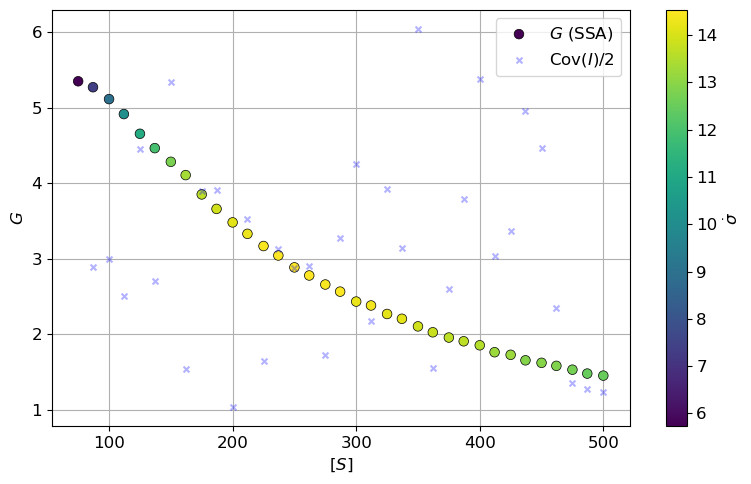

In [ ]:
SIM1.run_IF_sweep(

        species_index=[3],
        count_values=[np.linspace(75,500,35,dtype='int')],
        total_iterations=750, 
        covariance_reaction_indices=[0],   
        verbose=True)

module1_conductances, _ = SIM1.compute_conductances(analytical_currents=None, analytical_forces=None)

plot_conductance_publishable(
    SIM1,
    analytical_G=None,
    marker_size=60,
    cmap='viridis',
    show_covariance=True,
    species_index=0,
    x_axis_label=None,
    save_name='M1_conductance_plot.png'
)


SIM2.run_IF_sweep(

        species_index=[5],
        count_values=[np.linspace(75,500,35,dtype='int')],
        total_iterations=750, 
        covariance_reaction_indices=[2,4],   
        verbose=True)

module2_conductances, _ = SIM2.compute_conductances(analytical_currents=None, analytical_forces=None)

plot_conductance_publishable(
    SIM2,
    analytical_G=None,
    marker_size=60,
    cmap='viridis',
    show_covariance=True,
    species_index=0,
    x_axis_label=None,
    save_name='M2_conductance_plot.png'
)

In [8]:

# Find good B.C and I.C for M3 and M4

initial_counts3 = [200, 200, 200, 200, 200, 20, 20, 20,20,20,20] # Nb =30
rates3 = 0.1*np.array([0.1,0.15,0.5,0.01,0.07,0.12,0.4,0.09,0.2,0.04,0.3,0.01])

SIM3 = RunSSA(module3, initial_counts3, rates3, simulation_length, burn_in)

module3.fundamental_current_vector

# SIM3.run_SSA_and_plot_counts(True)

⎡-j₂⎤
⎢   ⎥
⎢-j₄⎥
⎢   ⎥
⎣-j₆⎦

In [35]:
SIM3.species_names

['C1', 'C2', 'C3', 'C4', 'C5', 'Ne', 'Nex', 'Nb', 'Pex', 'Pb', 'Pe']

In [9]:

# Find good B.C and I.C for M3 and M4

initial_counts4 = [100, 50, 100,50,20]

rates4 = 0.5*np.array([0.4,0.01,0.5,0.05,0.01,0.12,0.05,0.11,0.045,0.04])

SIM4 = RunSSA(module4, initial_counts4, rates4, simulation_length, 300) # Burn in for M4 is 300 (see counts vs time plot)

module4.fundamental_current_vector
# SIM4.run_SSA_and_plot_counts(True)

[-j₃ + j₅]

In [20]:
SIM4.species_names

['D1', 'D2', 'D3', 'Nd', 'S']

Sweep 1/35  ([Nd] = 10)
Sweep 2/35  ([Nd] = 12)


Sweep 3/35  ([Nd] = 15)
Sweep 4/35  ([Nd] = 17)
Sweep 5/35  ([Nd] = 20)
Sweep 6/35  ([Nd] = 23)
Sweep 7/35  ([Nd] = 25)
Sweep 8/35  ([Nd] = 28)
Sweep 9/35  ([Nd] = 31)
Sweep 10/35  ([Nd] = 33)
Sweep 11/35  ([Nd] = 36)
Sweep 12/35  ([Nd] = 39)
Sweep 13/35  ([Nd] = 41)
Sweep 14/35  ([Nd] = 44)
Sweep 15/35  ([Nd] = 47)
Sweep 16/35  ([Nd] = 49)
Sweep 17/35  ([Nd] = 52)
Sweep 18/35  ([Nd] = 55)
Sweep 19/35  ([Nd] = 57)
Sweep 20/35  ([Nd] = 60)
Sweep 21/35  ([Nd] = 62)
Sweep 22/35  ([Nd] = 65)
Sweep 23/35  ([Nd] = 68)
Sweep 24/35  ([Nd] = 70)
Sweep 25/35  ([Nd] = 73)
Sweep 26/35  ([Nd] = 76)
Sweep 27/35  ([Nd] = 78)
Sweep 28/35  ([Nd] = 81)
Sweep 29/35  ([Nd] = 84)
Sweep 30/35  ([Nd] = 86)
Sweep 31/35  ([Nd] = 89)
Sweep 32/35  ([Nd] = 92)
Sweep 33/35  ([Nd] = 94)
Sweep 34/35  ([Nd] = 97)
Sweep 35/35  ([Nd] = 100)
Total sweep time: 24.13 s


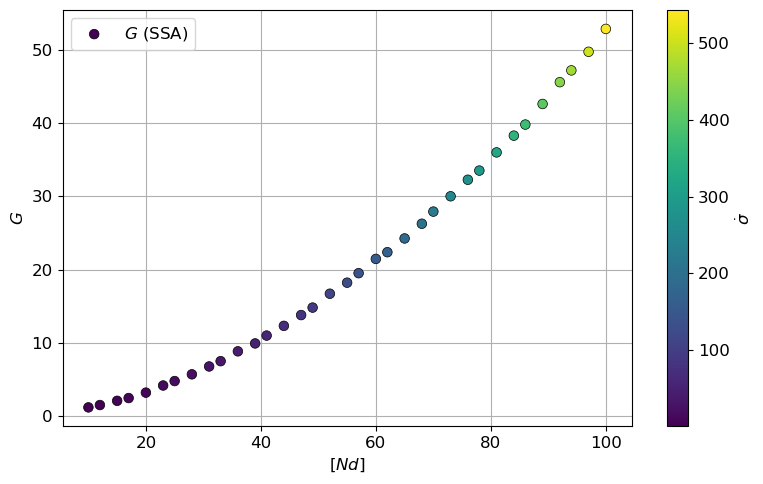

In [12]:
# SIM3.run_IF_sweep(

#         species_index=[6],
#         count_values=[np.linspace(20,300,35,dtype='int')],
#         total_iterations=750, 
#         covariance_reaction_indices=[1,3,5],   
#         verbose=True)

# module3_conductances, _ = SIM3.compute_conductances(analytical_currents=None, analytical_forces=None)

# plot_conductance_publishable(
#     SIM3,
#     analytical_G=None,
#     marker_size=60,
#     cmap='viridis',
#     show_covariance=False,
#     species_index=0,
#     x_axis_label=None,
#     save_name='M3_conductance_plot.png'
# )


SIM4.run_IF_sweep(

        species_index=[3], # vary Nd
        count_values=[np.linspace(10,100,35,dtype='int')],
        total_iterations=5, 
        covariance_reaction_indices=[2,4],   # I = -j3 + j5
        verbose=True)

module4_conductances, _ = SIM4.compute_conductances(analytical_currents=None, analytical_forces=None)

plot_conductance_publishable(
    SIM4,
    analytical_G=None,
    marker_size=60,
    cmap='viridis',
    show_covariance=False,
    species_index=0,
    x_axis_label=None,
    save_name='M4_conductance_plot.png'
)

In [38]:
SIM4.species_names

['D1', 'D2', 'D3', 'Nd', 'S']

# Find the SS vals of S, Na, Nb

In [3]:
from scipy.optimize import root
import numpy as np

def find_steady_state_all(
    mod1SIM,
    mod2SIM,
    mod3SIM,
    mod4SIM,
    species_info,
    initial_guess,
    iterations_per_eval=1,
):

    flux_cache = {}
    eval_counter = {"count": 0}  # mutable counter

    # ----------------------------
    # Helper: run SSA for a module
    # ----------------------------
    def run_flux_for_module(ssa_runner, fixed_species):
        pops = np.array(ssa_runner.initial_counts, dtype=float)
        for idx, val in fixed_species.items():
            pops[idx] = val

        flux_sum = None
        for _ in range(iterations_per_eval):
            ssa_runner.run_SSA_and_plot_counts(store_trajectories=False, starting_pops=pops)
            currents = np.array(ssa_runner.average_reaction_currents, dtype=float).flatten()
            if flux_sum is None:
                flux_sum = np.zeros_like(currents)
            flux_sum += currents
        return flux_sum / iterations_per_eval

    # ----------------------------
    # Helper: safe dot product
    # ----------------------------
    def safe_dot(modSIM, spec_index, flux, mod_name, spec_name):
        # convert stoichiometry matrix to NumPy if not already
        SM_np = np.array(modSIM.module.stoich_matrix, dtype=float)
        stoich_row = SM_np[spec_index, :].flatten()
        flux = np.array(flux, dtype=float).flatten()

        if stoich_row.shape[0] != flux.shape[0]:
            raise ValueError(
                f"Shape mismatch for species '{spec_name}' in {mod_name}: "
                f"stoich length = {stoich_row.shape[0]}, flux length = {flux.shape[0]}"
            )
        return np.dot(stoich_row, flux)

    # ----------------------------
    # Main residual function
    # ----------------------------
    def flux_balance_system(x):
        if np.any(x < 0):
            return np.ones_like(x) * 1e6

        key = tuple(np.round(x, 6))
        if key in flux_cache:
            return flux_cache[key]

        eval_counter["count"] += 1

        # Build fixed species dictionaries
        fixed_mod1 = {spec["index_mod1"]: x[i] for i, spec in enumerate(species_info) if spec["index_mod1"] is not None}
        fixed_mod2 = {spec["index_mod2"]: x[i] for i, spec in enumerate(species_info) if spec["index_mod2"] is not None}
        fixed_mod3 = {spec["index_mod3"]: x[i] for i, spec in enumerate(species_info) if spec["index_mod3"] is not None}
        fixed_mod4 = {spec["index_mod4"]: x[i] for i, spec in enumerate(species_info) if spec["index_mod4"] is not None}

        # Run modules
        flux1 = run_flux_for_module(mod1SIM, fixed_mod1)
        flux2 = run_flux_for_module(mod2SIM, fixed_mod2)
        flux3 = run_flux_for_module(mod3SIM, fixed_mod3)
        flux4 = run_flux_for_module(mod4SIM, fixed_mod4)

        residuals = []
        for i, spec in enumerate(species_info):
            res = 0.0
            if spec["index_mod1"] is not None:
                stoich_row = mod1SIM.module.stoich_matrix[spec["index_mod1"]]
                res += safe_dot(mod1SIM, spec["index_mod1"], flux1, "mod1SIM", spec["name"])
            if spec["index_mod2"] is not None:
                stoich_row = mod2SIM.module.stoich_matrix[spec["index_mod2"]]
                res += safe_dot(mod2SIM, spec["index_mod2"], flux2, "mod2SIM", spec["name"])
            if spec["index_mod3"] is not None:
                stoich_row = mod3SIM.module.stoich_matrix[spec["index_mod3"]]
                res += safe_dot(mod3SIM, spec["index_mod3"], flux3, "mod3SIM", spec["name"])
            if spec["index_mod4"] is not None:
                stoich_row = mod4SIM.module.stoich_matrix[spec["index_mod4"]]
                res += safe_dot(mod4SIM, spec["index_mod4"], flux4, "mod4SIM", spec["name"])
            residuals.append(res)

        residuals = np.array(residuals, dtype=float)

        # 🔥 Progress print
        if eval_counter["count"] % 5 == 0:
            norm = np.linalg.norm(residuals)
            values_str = ", ".join(f"{species_info[i]['name']}={x[i]:.2f}" for i in range(len(x)))
            print(f"[Eval {eval_counter['count']}] | Residual norm = {norm:.4e} | {values_str}")

        flux_cache[key] = residuals
        return residuals

    # ----------------------------
    # Solve steady-state
    # ----------------------------
    print("Starting steady-state solve...\n")
    sol = root(flux_balance_system, initial_guess, method='broyden1', tol=1e-8)
    print("\nFinished.")
    print(f"Total function evaluations: {eval_counter['count']}")
    print(f"Success: {sol.success}")
    print(f"Message: {sol.message}\n")
    return sol

In [15]:
SIM4.species_names

['D1', 'D2', 'D3', 'Nd', 'S']

In [4]:
species_info = [
    {
        "name": "S",
        "index_mod1": SIM1.species_names.index("S"),
        "index_mod2": None,
        "index_mod3": None,
        "index_mod4": SIM4.species_names.index("S"),
    },
    {
        "name": "Na",
        "index_mod1": SIM1.species_names.index("Na"),
        "index_mod2": SIM2.species_names.index("Na"),
        "index_mod3": None,
        "index_mod4": None,
    },
    {
        "name": "Nb",
        "index_mod1": None,
        "index_mod2": SIM2.species_names.index("Nb"),
        "index_mod3": SIM3.species_names.index("Nb"),
        "index_mod4": None,
    },
]

initial_guess = [300,300,300]  # [S, Na, Nb]

solution = find_steady_state_all(
    SIM1,
    SIM2,
    SIM3,
    SIM4,
    species_info,
    initial_guess,
    iterations_per_eval=1
)

print(solution.success)   # Did it converge?
print(solution.message)   # Why/why not

steady_state_values = solution.x

print(steady_state_values)

NameError: name 'SIM1' is not defined

# SEPERATE SIM THEN COMVINE

## Run to get a single global CM. This means have a single set of boundary conditions, where we require S = 153, Na = 83, Nb = 30 (other chemostats are free)

In [27]:
# Module 1

SM = Matrix( [[-1,1,0], [1,-1,-1], [0,0,1], [-1,0,-1], [0,1,0]])

species_names = ["A1", "A2","A3","S","Na"]

num_internal_species = 3

# Module 2


SM2 = Matrix([[-1, 0, 1, 0, 0], # first row of internal
                           [1, -1, 0, -1, 0], 
                           [0, 1, -1, 0, 1], 
                           [0, 0, 0, 1, -1],
                             [0, 0, 0, -1, 0], # first row external 
                             [0, 0, 0, 0, 1],
                             [-1, 0, 0, 0, 0],
                             [0, 0, 1, 0, 0]])


species_names2 = ["B1", "B2", "B3", "B4", "Na", "Nb", "F", "W"]

num_internal_species2 = 4

# Module 3

SM3 = Matrix([
    [ 1, -1,  0,  0,  0,  0],  # EcNex
    [-1,  1, -1,  1,  0,  0],  # Ec
    [ 0,  0,  1, -1,  0,  0],  # EcNb
    [ 0,  0,  0,  0, -1,  1],  # Ec*
    [ 0,  0,  0,  0,  1, -1],  # Ec*Ne
    [ 0,  0,  0,  0, -1,  0],  # Ne
    [-1,  0,  0,  0,  0,  0],  # Nex
    [ 0,  0, -1,  0,  0,  0],  # Nb
    [ 0,  1,  0,  0,  0,  0],  # Pex
    [ 0,  0,  0,  1,  0,  0],  # Pb  # col 4 entry uncertain
    [ 0,  0,  0,  0,  0,  1],  # Pe
])

species_names3 = ["C1", "C2", "C3", "C4", "C5", "Ne", "Nex", "Nb", "Pex", "Pb", "Pe"]

# Module 4

SM4 = Matrix([
    [ 1,  1, -1,  0,  1],  # Ed
    [-1, -1,  1,  1,  0],  # EdS
    [ 0,  1,  0, -1, -1],  # Ed*
    [ 0,  0, -1, -1,  0],  # Nd
    [ 1,  0,  0,  0,  0],  # S
])

species_names4 = ["D1", "D2", "D3", "Nd", "S"]


module1 = ModuleProperties(SM, 3, species_names)
display(module1.calculate_fundamental_resistance_matrix())

module2 = ModuleProperties(SM2, 4, species_names2)
display(module2.calculate_fundamental_resistance_matrix())

module3 = ModuleProperties(SM3, 5, species_names3)
display(module3.calculate_fundamental_resistance_matrix())

module4 = ModuleProperties(SM4, 3, species_names4)
display(module4.calculate_fundamental_resistance_matrix())

[r₁ + r₂]

⎡r₂ + r₄ + r₅      -r₂     ⎤
⎢                          ⎥
⎣    -r₂       r₁ + r₂ + r₃⎦

⎡r₁ + r₂     0        0   ⎤
⎢                         ⎥
⎢   0     r₃ + r₄     0   ⎥
⎢                         ⎥
⎣   0        0     r₅ + r₆⎦

⎡r₁⋅r₃ + r₁⋅r₄ + r₁⋅r₅ + r₃⋅r₄ + r₃⋅r₅⎤
⎢─────────────────────────────────────⎥
⎣            r₃ + r₄ + r₅             ⎦

In [43]:
print(SIM1.species_names)
print(SIM2.species_names)
print(SIM3.species_names)
print(SIM4.species_names)


['A1', 'A2', 'A3', 'S', 'Na']
['B1', 'B2', 'B3', 'B4', 'Na', 'Nb', 'F', 'W']
['C1', 'C2', 'C3', 'C4', 'C5', 'Ne', 'Nex', 'Nb', 'Pex', 'Pb', 'Pe']
['D1', 'D2', 'D3', 'Nd', 'S']


In [28]:
simulation_length = 1000.0

burn_in = 200.0

initial_counts = [350, 350, 350, 133, 88] # S = 153, Na = 83

rates = 0.1 * np.array([0.005, 0.8, 0.6, 0.002, 0.012, 0.5])

SIM1 = RunSSA(module1, initial_counts, rates, simulation_length, burn_in)

initial_counts2 = [350, 350, 350, 350, 88, 25, 50, 50] # Na = 83, Nb = 30

rates2 = 0.1 * np.array([0.01, 1.0, 1.0, 0.5, 1.5, 0.01, 0.01, 1.0, 1.2, 0.01])

SIM2 = RunSSA(module2, initial_counts2, rates2, simulation_length,burn_in)

# SIM2.run_SSA_and_plot_counts(True)
# Find good B.C and I.C for M3 and M4

initial_counts3 = [200, 200, 200, 200, 200, 20, 20, 25,20,20,20] # Nb =30
rates3 = 0.1*np.array([0.1,0.15,0.5,0.01,0.07,0.12,0.4,0.09,0.2,0.04,0.3,0.01])

SIM3 = RunSSA(module3, initial_counts3, rates3, simulation_length, burn_in)



# SIM3.run_SSA_and_plot_counts(True)
# Find good B.C and I.C for M3 and M4

initial_counts4 = [100, 50, 100,50,133]

rates4 = 0.5*np.array([0.4,0.01,0.5,0.05,0.01,0.12,0.05,0.11,0.045,0.04])

SIM4 = RunSSA(module4, initial_counts4, rates4, simulation_length, 300) # Burn in for M4 is 300 (see counts vs time plot)

# module4.fundamental_current_vector
# SIM4.run_SSA_and_plot_counts(True)

In [29]:
# Do a single run.

SIM1.run_IF_sweep(

        species_index=[0],
        count_values=[np.array([initial_counts[0]])],
        total_iterations=5, 
        covariance_reaction_indices=None,   
        verbose=True)


SIM2.run_IF_sweep(

        species_index=[0],
        count_values=[np.array([initial_counts2[0]])],
        total_iterations=5, 
        covariance_reaction_indices=None,   
        verbose=True)

SIM3.run_IF_sweep(

        species_index=[0],
        count_values=[np.array([initial_counts3[0]])],
        total_iterations=5, 
        covariance_reaction_indices=None,   
        verbose=True)


SIM4.run_IF_sweep(

        species_index=[0], 
        count_values=[np.array([initial_counts4[0]])],
        total_iterations=5, 
        covariance_reaction_indices=None,   # I = -j3 + j5
        verbose=True)

# FIND SEPERATE CMS
module1_conductances, _ = SIM1.compute_conductances(analytical_currents=None, analytical_forces=None)
module2_conductances, _ = SIM2.compute_conductances(analytical_currents=None, analytical_forces=None)
module3_conductances, _ = SIM3.compute_conductances(analytical_currents=None, analytical_forces=None)
module4_conductances, _ = SIM4.compute_conductances(analytical_currents=None, analytical_forces=None)



Sweep 1/1  ([A1] = 350)
Total sweep time: 0.19 s
Sweep 1/1  ([B1] = 350)
Total sweep time: 0.41 s
Sweep 1/1  ([C1] = 200)
Total sweep time: 0.24 s
Sweep 1/1  ([D1] = 100)
Total sweep time: 1.25 s


In [30]:
display(module1_conductances)
display(module2_conductances)
display(module3_conductances)
display(module4_conductances)

[[5.29831770089205]]

⎡⎡5.58563104515535  2.6399290488506 ⎤⎤
⎢⎢                                  ⎥⎥
⎣⎣2.6399290488506   10.3007879240543⎦⎦

⎡⎡2.28569516106413         0                 0        ⎤⎤
⎢⎢                                                    ⎥⎥
⎢⎢       0          4.20840955038975         0        ⎥⎥
⎢⎢                                                    ⎥⎥
⎣⎣       0                 0          2.08335796178941⎦⎦

[[36.7900564419001]]

In [31]:
# SERIALLY COMBINE

# combine M1 and M2
M1_and_M2 = CombiningModules(module1, module2, module1_conductances, module2_conductances)

combined_Gs_JN1 = M1_and_M2.numerical_combined_fundamental_CMs
display(combined_Gs_JN1[0].inv())

⎡ 0.392444182622431   -0.0522063774796736⎤
⎢                                        ⎥
⎣-0.0522063774796736   0.110459621228278 ⎦

In [32]:
# combine (M1 + M2) + M3

with_M3 = CombiningModules(M1_and_M2, module3, combined_Gs_JN1, module3_conductances)

combined_Gs_JN2 = with_M3.numerical_combined_fundamental_CMs
display(combined_Gs_JN2)

⎡⎡2.64372979295035  -2.1632377170877   1.72528036875998   1.72528036875998 ⎤⎤
⎢⎢                                                                         ⎥⎥
⎢⎢-2.1632377170877  7.76198164721934   -4.53167463558416  -4.53167463558416⎥⎥
⎢⎢                                                                         ⎥⎥
⎢⎢1.72528036875998  -4.53167463558416  23.9232759195808   7.08963771802176 ⎥⎥
⎢⎢                                                                         ⎥⎥
⎣⎣1.72528036875998  -4.53167463558416  7.08963771802176   7.08963771802176 ⎦⎦

In [33]:
# combine M4 + ((M1 + M2) + M3)

with_M4 = CombiningModules(module4, with_M3, module4_conductances, combined_Gs_JN2)

combined_Gs_JN3 = with_M4.numerical_combined_fundamental_CMs
display(combined_Gs_JN3)

⎡⎡2.46648819670829   -2.01820939117858   1.609613689306     1.609613689306  ⎤⎤
⎢⎢                                                                          ⎥⎥
⎢⎢-2.01820939117858  7.64331190060254   -4.43703012075048  -4.43703012075048⎥⎥
⎢⎢                                                                          ⎥⎥
⎢⎢ 1.609613689306    -4.43703012075048  23.8477926187103   7.01415441715125 ⎥⎥
⎢⎢                                                                          ⎥⎥
⎣⎣ 1.609613689306    -4.43703012075048  7.01415441715125   7.01415441715125 ⎦⎦

In [35]:
M4_M1 = CombiningModules(module4, module1, module4_conductances, module1_conductances)
JN1_CM = M4_M1.numerical_combined_fundamental_CMs

M2_M3 = CombiningModules(module2, module3, module2_conductances, module3_conductances)
JN2_CM = M2_M3.numerical_combined_fundamental_CMs

FUll_network = CombiningModules(M4_M1, M2_M3, JN1_CM, JN2_CM)
FUll_network.numerical_combined_fundamental_CMs


⎡⎡2.46648819670828   -2.01820939117858   1.609613689306     1.609613689306  ⎤⎤
⎢⎢                                                                          ⎥⎥
⎢⎢-2.01820939117858  7.64331190060254   -4.43703012075048  -4.43703012075048⎥⎥
⎢⎢                                                                          ⎥⎥
⎢⎢ 1.609613689306    -4.43703012075048  23.8477926187103   7.01415441715125 ⎥⎥
⎢⎢                                                                          ⎥⎥
⎣⎣ 1.609613689306    -4.43703012075048  7.01415441715126   7.01415441715126 ⎦⎦

In [101]:
display(combined_Gs_JN1)
display(combined_Gs_JN2)

[[4.35949511166711]]

⎡⎡ 5.441473575501    -4.49989273574882  3.58272289935034   3.58272289935034 ⎤⎤
⎢⎢                                                                          ⎥⎥
⎢⎢-4.49989273574882   9.4649189187143   -5.92476985878736  -5.92476985878736⎥⎥
⎢⎢                                                                          ⎥⎥
⎢⎢3.58272289935034   -5.92476985878736  26.1656306128049   8.20609795716898 ⎥⎥
⎢⎢                                                                          ⎥⎥
⎣⎣3.58272289935034   -5.92476985878736  8.20609795716898   8.20609795716898 ⎦⎦

# BY DIRECT SIM 

In [36]:
# SERIALLY COMBINE

# combine M1 and M4
JN1_M1_and_M2 = CombiningModules(module1, module2)

JN1 = ModuleProperties(JN1_M1_and_M2.stoich_matrix, JN1_M1_and_M2.num_internal_species, JN1_M1_and_M2.species_names)
JN1.calculate_fundamental_resistance_matrix()

# combine M2 and M3
JN1_and_M3 = CombiningModules(JN1, module3)

JN2 = ModuleProperties(JN1_and_M3.stoich_matrix, JN1_and_M3.num_internal_species, JN1_and_M3.species_names)
JN2.calculate_fundamental_resistance_matrix()

# combine the two new joint networks

JN3_total_network = CombiningModules(module4,JN2)

JN3 = ModuleProperties(JN3_total_network.stoich_matrix, JN3_total_network.num_internal_species, JN3_total_network.species_names)
JN3.calculate_fundamental_resistance_matrix()


KeyboardInterrupt: 

In [37]:
# combine M1 and M2
JN1_M1_and_M2 = CombiningModules(module1, module2, module1_conductances, module2_conductances)
combined_Gs_JN1 = JN1_M1_and_M2.numerical_combined_fundamental_CMs

# combine JN1 and M3
JN1_and_M3 = CombiningModules(JN1_M1_and_M2, module3, combined_Gs_JN1, module3_conductances)
combined_Gs_JN2 = JN1_and_M3.numerical_combined_fundamental_CMs

# combine with M4 — pass JN1_and_M3 directly, NOT a reconstructed ModuleProperties
JN3 = CombiningModules(module4, JN1_and_M3, module4_conductances, combined_Gs_JN2)

global_conductance = JN3.numerical_combined_fundamental_CMs
display(global_conductance[0].inv())

⎡ 0.529001355340073      0.109375915152049    1.73472347597681e-18   -0.052206 ↪
⎢                                                                              ↪
⎢ 0.109375915152049      0.229374496569749    -3.46944695195361e-18    0.11999 ↪
⎢                                                                              ↪
⎢1.73472347597681e-18  -6.93889390390723e-18   0.0594048647135227    -0.059404 ↪
⎢                                                                              ↪
⎣-0.0522063774796736      0.1199985814177      -0.0594048647135227     0.28986 ↪

↪ 3774796736⎤
↪           ⎥
↪ 85814177  ⎥
↪           ⎥
↪ 8647135227⎥
↪           ⎥
↪ 30673595  ⎦

In [46]:
# Create combined rates and counts

JN1_combined_initial_counts, JN1_combined_rates = JN1_M1_and_M2.build_combined_initial_counts_and_rates(
    left_initial_counts  = initial_counts,
    right_initial_counts = initial_counts2,
    left_rates = rates,
    right_rates = rates2
)

JN2_combined_initial_counts, JN2_combined_rates = JN1_and_M3.build_combined_initial_counts_and_rates(
    left_initial_counts  = JN1_combined_initial_counts,
    right_initial_counts = initial_counts3,
    left_rates = JN1_combined_rates,
    right_rates = rates3
)

JN3_combined_initial_counts, JN3_combined_rates = JN3_total_network.build_combined_initial_counts_and_rates(
    left_initial_counts  = initial_counts4,
    right_initial_counts = JN2_combined_initial_counts,
    left_rates = rates4,
    right_rates = JN2_combined_rates
)

SIM_JN3 = RunSSA(JN3, JN3_combined_initial_counts, JN3_combined_rates, 1000 , 400)


=== Overlapping species detected ===
  ['Na']
These species appear in both modules and are now internal.
Please enter a single initial count for each:

  Species 'Na':
    Left  module value : 88
    Right module value : 88

=== Combined initial counts ===
  [0] A1           : 350
  [1] A2           : 350
  [2] A3           : 350
  [3] Na           : 88.0 ← user entered
  [4] B1           : 350
  [5] B2           : 350
  [6] B3           : 350
  [7] B4           : 350
  [8] S            : 133
  [9] Nb           : 25
  [10] F            : 50
  [11] W            : 50

=== Combined rates ===
  Reaction  1 (left ) : k+ = 0.0005,  k- = 0.08
  Reaction  2 (left ) : k+ = 0.06,  k- = 0.0002
  Reaction  3 (left ) : k+ = 0.0012,  k- = 0.05
  Reaction  4 (right) : k+ = 0.001,  k- = 0.1
  Reaction  5 (right) : k+ = 0.1,  k- = 0.05
  Reaction  6 (right) : k+ = 0.15,  k- = 0.001
  Reaction  7 (right) : k+ = 0.001,  k- = 0.1
  Reaction  8 (right) : k+ = 0.12,  k- = 0.001

=== Overlapping species det

In [47]:

initial_counts_JN3 = SIM_JN3.initial_counts

SIM_JN3.run_IF_sweep(

        species_index=[0], 
        count_values=[np.array([initial_counts_JN3[0]])],
        total_iterations=5, 
        covariance_reaction_indices=None,   # I = -j3 + j5
        verbose=True)

# FIND CMS
JN3_conductances, _ = SIM_JN3.compute_conductances(analytical_currents=None, analytical_forces=None)

display(JN3_conductances[0])

Sweep 1/1  ([D1] = 100)
Total sweep time: 11.41 s


⎡9.51848627526442         0          0.72577485074191         0        ⎤
⎢                                                                      ⎥
⎢       0          2.19644626021952         0                 0        ⎥
⎢                                                                      ⎥
⎢0.72577485074191         0          1.58231808063763         0        ⎥
⎢                                                                      ⎥
⎣       0                 0                 0          2.10165953052786⎦

Combined eigenvalues:  [ 1.84957589  2.5884848   8.03587554 18.3968894 ]
Direct   eigenvalues:  [1.51649086 2.10165953 2.19644626 9.5843135 ]
Max absolute diff:     8.812575898795389
Max relative diff:     2.6585805387465684
Matrices match:        False


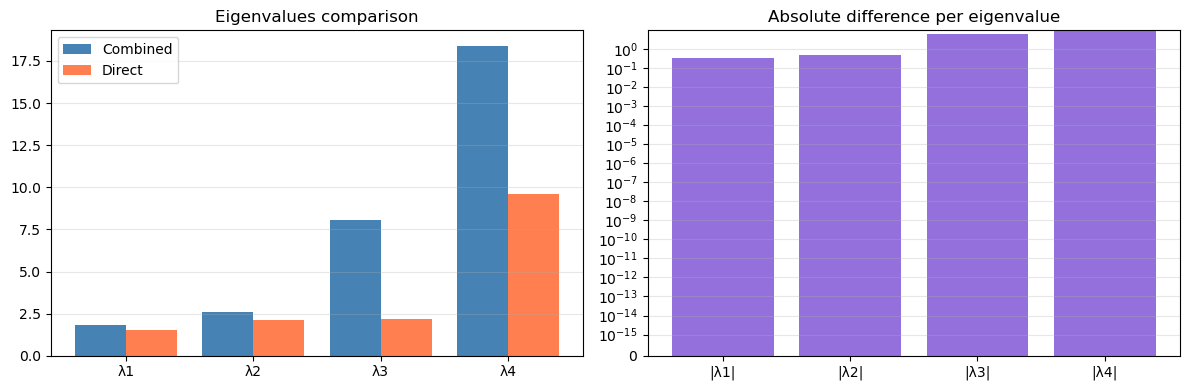

In [48]:
import numpy as np
import matplotlib.pyplot as plt

def clean_matrix(mat, threshold=1e-14):
    """Replace near-zero, NaN, and Inf values."""
    mat = np.array(mat, dtype=complex)
    mat = np.where(np.isnan(mat), 0, mat)
    mat = np.where(np.isinf(mat), 0, mat)
    mat = np.where(np.abs(mat) < threshold, 0, mat)
    return mat

def get_eigenvalues(mat, threshold=1e-14):
    mat = clean_matrix(mat, threshold)
    eigs = np.linalg.eigvals(mat)
    eigs = np.where(np.abs(eigs.real) < threshold, 0, eigs.real)
    return np.sort(eigs.real)

# --- Your matrices here ---
comb_matrix  = np.array(global_conductance[0].tolist(), dtype=float)
direct_matrix = np.array(JN3_conductances[0].tolist(), dtype=float)

comb_evals  = get_eigenvalues(comb_matrix)
direct_evals = get_eigenvalues(direct_matrix)

print("Combined eigenvalues: ", comb_evals)
print("Direct   eigenvalues: ", direct_evals)
print("Max absolute diff:    ", np.max(np.abs(comb_evals - direct_evals)))
print("Max relative diff:    ", np.max(np.abs(comb_evals - direct_evals) / (np.abs(direct_evals) + 1e-30)))
print("Matrices match:       ", np.allclose(comb_evals, direct_evals, atol=1e-10))

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x = np.arange(len(comb_evals))
axes[0].bar(x - 0.2, comb_evals,  0.4, label='Combined',  color='steelblue')
axes[0].bar(x + 0.2, direct_evals, 0.4, label='Direct',    color='coral')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'λ{i+1}' for i in x])
axes[0].set_title('Eigenvalues comparison')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

diff = np.abs(comb_evals - direct_evals)
axes[1].bar(x, diff, color='mediumpurple')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'|λ{i+1}|' for i in x])
axes[1].set_title('Absolute difference per eigenvalue')
axes[1].set_yscale('symlog', linthresh=1e-15)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [38]:
def get_steady_state_values(sim, species_of_interest):
    """
    Extract steady state values (final timepoint) from a RunSSA object.
    
    Parameters
    ----------
    sim : RunSSA
        A RunSSA object after calling run_SSA_and_plot_counts().
    species_of_interest : list of str
        Species names to extract, e.g. ['S', 'Na', 'Nb'].
    
    Returns
    -------
    dict : {species_name: final_count}
    """
    if not hasattr(sim, 'final_pops'):
        raise RuntimeError("No final_pops found. Call sim.run_SSA_and_plot_counts() first.")
    
    name_to_final = dict(zip(sim.species_names, sim.final_pops))
    
    results = {}
    for species in species_of_interest:
        if species in name_to_final:
            results[species] = name_to_final[species]
        else:
            print(f"Warning: '{species}' not found in simulation. "
                  f"Available species: {sim.species_names}")
    
    return results


# --- Usage ---
SIM_JN3.run_SSA_and_plot_counts(store_trajectories=False)

steady_state = get_steady_state_values(SIM_JN3, ['S', 'Na', 'Nb'])

for name, val in steady_state.items():
    print(f"{name}: {val}")

NameError: name 'SIM_JN3' is not defined